
# Triadic Cell Notebook v9
## Supervised slots, novelty-gated writes, controlled rewrite isolation

v8 was the first real task-level success:
- BTR beat the baseline on retrieval accuracy
- BTR beat the baseline on recall similarity
- BTR beat the baseline on slot divergence
- but rewrite locality was still too global

v9 tightens the benchmark.

## What changes in v9

1. **Supervised slot contract**
   - each prototype is assigned to one specific slot
   - storage writes are routed to that target slot during benchmark setup

2. **Novelty-gated write**
   - if recalled content already matches the incoming pattern,
     the write is suppressed
   - this should reduce pointless overwrite and rewrite spill

3. **Orthogonalized patterns**
   - the stored prototypes are cleaner and less overlapping

4. **Controlled rewrite isolation**
   - we compare:
     - bank after storage
     - bank after passive decay only
     - bank after actual rewrite
   - this separates true rewrite from leak/decay

The benchmark question is now:

> can the triadic machine store, recall, and selectively rewrite
> slot-bound memories better than the baseline?



## Hardware translation

Use the machine picture directly:

- **Binding (B)** = preserve identity and protect writes
- **Transformation (T)** = update latent state toward targets
- **Readout (R)** = expose meaningful delta
- **Address lines** = fixed slot keys
- **Supervised slot contract** = known storage location for each prototype
- **Novelty gate** = only write when the new pattern is meaningfully different from recalled content
- **Controlled rewrite isolation** = measure true update, not just decay

This is the first benchmark that asks the machine to obey
an explicit memory contract.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)

        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 2):
        self.slots *= (1.0 - self.leak)

        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(
                self.slots[i] + strength * masked[i] * value,
                0.0, 1.0
            )

        return masked.copy()

    def decay_only(self, steps: int = 1):
        self.slots *= (1.0 - self.leak) ** steps

    def mean_level(self) -> float:
        return float(self.slots.mean())

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def divergence(self) -> float:
        e = self.slot_energy()
        if np.allclose(e.sum(), 0.0):
            return 0.0
        return float(np.std(e))



## Models

Both models support:

- `probe(...)` for read-only recall
- `step(...)` for storage/update
- optional `target_slot`
- novelty-gated writes


In [4]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))


class TriadicCellV9:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = self._query(cue)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        write_enabled: bool = True,
        target_slot: int | None = None,
        novelty_threshold: float = 0.10,
    ):
        query = self._query(s.latent)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)

        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        base_write_strength = float(0.60 * support * readout.mean())

        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        if target_slot is not None:
            weights = np.zeros(4, dtype=float)
            weights[target_slot] = 1.0
        else:
            weights = addr

        if write_enabled:
            bank.write(weights, latent, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, recalled.copy(), addr.copy(), write_strength, novelty


class PlainTRBaselineV9:
    def __init__(self):
        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = cue / (np.linalg.norm(cue) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        write_enabled: bool = True,
        target_slot: int | None = None,
        novelty_threshold: float = 0.10,
    ):
        query = s.latent / (np.linalg.norm(s.latent) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        coherence = float(np.clip(s.coherence - 0.08 - 0.02 * np.linalg.norm(s.readout), 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        latent = self._clip(s.latent + 0.10 * coherence * (composite_target - s.latent) - 0.18 * s.latent)

        delta_vec = np.abs(latent - s.latent)
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)
        readout = self._clip(0.65 * s.readout + 1.35 * projected - 0.35 * s.readout)

        base_write_strength = float(0.08 * readout.mean())
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        if target_slot is not None:
            weights = np.zeros(4, dtype=float)
            weights[target_slot] = 1.0
        else:
            weights = addr

        if write_enabled:
            bank.write(weights, latent, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, recalled.copy(), addr.copy(), write_strength, novelty



## Orthogonalized prototype patterns

These are cleaner than v8.
Each pattern is assigned to one slot explicitly.


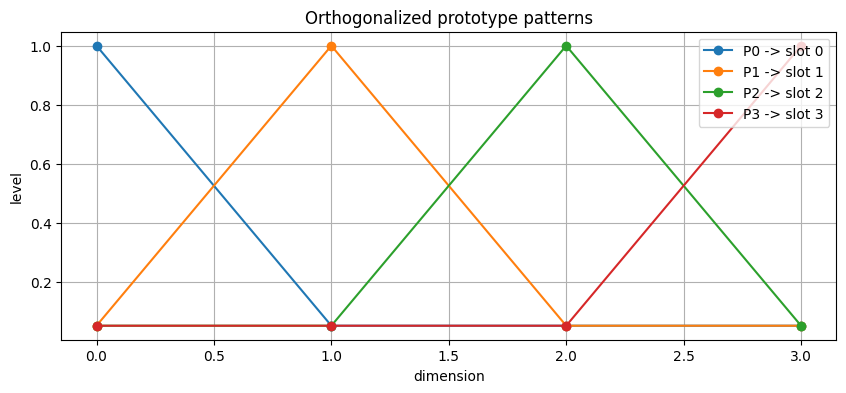

,d0,d1,d2,d3
P0,1.00,0.05,0.05,0.05
P1,0.05,1.00,0.05,0.05
P2,0.05,0.05,1.00,0.05
P3,0.05,0.05,0.05,1.00


In [5]:

patterns = np.array([
    [1.00, 0.05, 0.05, 0.05],  # -> slot 0
    [0.05, 1.00, 0.05, 0.05],  # -> slot 1
    [0.05, 0.05, 1.00, 0.05],  # -> slot 2
    [0.05, 0.05, 0.05, 1.00],  # -> slot 3
], dtype=float)

pattern_names = [f"P{i}" for i in range(patterns.shape[0])]

plt.figure(figsize=(10, 4))
for i, p in enumerate(patterns):
    plt.plot(p, marker="o", label=f"{pattern_names[i]} -> slot {i}")
plt.title("Orthogonalized prototype patterns")
plt.xlabel("dimension")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()

pd.DataFrame(patterns, index=pattern_names, columns=[f"d{i}" for i in range(4)])



## Helpers


In [6]:

def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    cue = np.clip(cue, 0.0, 1.0)
    return cue


def store_patterns_supervised(model, bank: KeyedMemoryBank, cycles_per_pattern: int = 18):
    state = AddressedTriadicState()
    rows = []

    for slot_idx, p in enumerate(patterns):
        for c in range(cycles_per_pattern):
            drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)
            state, recalled, addr, write_strength, novelty = model.step(
                state, drive, bank, write_enabled=True, target_slot=slot_idx, novelty_threshold=0.10
            )
            rows.append({
                "slot": slot_idx,
                "cycle": c,
                "write_strength": write_strength,
                "novelty": novelty,
            })

    return state, pd.DataFrame(rows)


def probe_patterns(model, bank: KeyedMemoryBank, trials_per_pattern: int = 24) -> pd.DataFrame:
    rows = []
    for idx, p in enumerate(patterns):
        for trial in range(trials_per_pattern):
            cue = partial_cue(p, mask_prob=0.5, noise=0.04)
            addr, recalled = model.probe(cue, bank)
            pred_slot = int(np.argmax(addr))
            sim = cosine_similarity(recalled, p)
            rows.append({
                "target_slot": idx,
                "pred_slot": pred_slot,
                "slot_focus": float(addr.max()),
                "recall_similarity": sim,
                "cue_mean": float(cue.mean()),
            })
    return pd.DataFrame(rows)


def controlled_rewrite_isolation(model, bank: KeyedMemoryBank, slot_idx: int = 2, cycles: int = 16):
    before = bank.slot_energy().copy()

    # passive decay control
    control_bank = copy.deepcopy(bank)
    control_bank.decay_only(steps=cycles)
    after_control = control_bank.slot_energy().copy()

    # actual rewrite
    rewrite_bank = copy.deepcopy(bank)
    modified = patterns[slot_idx].copy()
    modified = np.clip(modified * np.array([0.90, 1.05, 0.85, 1.00]), 0.0, 1.0)

    state = AddressedTriadicState()
    for _ in range(cycles):
        drive = np.clip(modified + rng.normal(0.0, 0.03, size=modified.shape[0]), 0.0, 1.0)
        state, *_ = model.step(
            state, drive, rewrite_bank, write_enabled=True, target_slot=slot_idx, novelty_threshold=0.10
        )

    after_rewrite = rewrite_bank.slot_energy().copy()

    isolated_delta = after_rewrite - after_control
    target_isolated_shift = float(abs(isolated_delta[slot_idx]))
    collateral_isolated_shift = float(np.mean(np.abs(np.delete(isolated_delta, slot_idx))))

    return {
        "before": before,
        "after_control": after_control,
        "after_rewrite": after_rewrite,
        "target_isolated_shift": target_isolated_shift,
        "collateral_isolated_shift": collateral_isolated_shift,
        "rewrite_isolation_ratio": float(target_isolated_shift / (collateral_isolated_shift + 1e-8)),
    }



## Run the benchmark


In [7]:

def run_benchmark(label: str, triadic: bool = True):
    if triadic:
        model = TriadicCellV9(1.0, 1.0, 1.0)
    else:
        model = PlainTRBaselineV9()

    bank = KeyedMemoryBank(width=4, leak=0.015)

    _, store_log = store_patterns_supervised(model, bank, cycles_per_pattern=18)
    slot_energy_after_store = bank.slot_energy().copy()

    probe_df = probe_patterns(model, bank, trials_per_pattern=24)

    accuracy = float((probe_df["pred_slot"] == probe_df["target_slot"]).mean())
    mean_similarity = float(probe_df["recall_similarity"].mean())
    mean_focus = float(probe_df["slot_focus"].mean())
    divergence = float(np.std(slot_energy_after_store))

    rewrite_stats = controlled_rewrite_isolation(model, bank, slot_idx=2, cycles=16)

    summary = {
        "model": label,
        "retrieval_accuracy": accuracy,
        "mean_recall_similarity": mean_similarity,
        "mean_slot_focus": mean_focus,
        "slot_divergence_after_store": divergence,
        "rewrite_target_isolated_shift": rewrite_stats["target_isolated_shift"],
        "rewrite_collateral_isolated_shift": rewrite_stats["collateral_isolated_shift"],
        "rewrite_isolation_ratio": rewrite_stats["rewrite_isolation_ratio"],
        "mean_write_strength": float(store_log["write_strength"].mean()),
        "mean_novelty": float(store_log["novelty"].mean()),
    }

    return summary, probe_df, store_log, slot_energy_after_store, rewrite_stats

triadic_summary, triadic_probe, triadic_store_log, triadic_store_energy, triadic_rewrite = run_benchmark("BTR", triadic=True)
baseline_summary, baseline_probe, baseline_store_log, baseline_store_energy, baseline_rewrite = run_benchmark("Plain TR baseline", triadic=False)

summary_df = pd.DataFrame([triadic_summary, baseline_summary])
summary_df


,model,retrieval_accuracy,mean_recall_similarity,mean_slot_focus,slot_divergence_after_store,rewrite_target_isolated_shift,rewrite_collateral_isolated_shift,rewrite_isolation_ratio,mean_write_strength,mean_novelty
0,BTR,0.541667,0.619052,0.912277,0.023231,0.014502,6.938894e-18,1.450241e+06,0.023040,0.287140
1,Plain TR baseline,0.385417,0.518240,0.947369,0.000232,0.000267,1.807004e-20,2.669154e+04,0.000174,0.374631



## Probe summary


In [8]:

probe_summary = pd.DataFrame([
    {
        "model": "BTR",
        "accuracy": (triadic_probe["pred_slot"] == triadic_probe["target_slot"]).mean(),
        "mean_similarity": triadic_probe["recall_similarity"].mean(),
        "mean_focus": triadic_probe["slot_focus"].mean(),
    },
    {
        "model": "Plain TR baseline",
        "accuracy": (baseline_probe["pred_slot"] == baseline_probe["target_slot"]).mean(),
        "mean_similarity": baseline_probe["recall_similarity"].mean(),
        "mean_focus": baseline_probe["slot_focus"].mean(),
    }
])
probe_summary


,model,accuracy,mean_similarity,mean_focus
0,BTR,0.541667,0.619052,0.912277
1,Plain TR baseline,0.385417,0.518240,0.947369


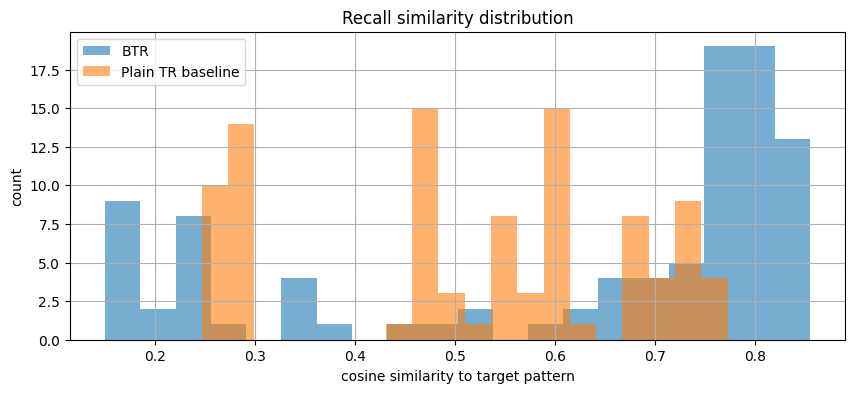

In [9]:

plt.figure(figsize=(10, 4))
plt.hist(triadic_probe["recall_similarity"], bins=20, alpha=0.6, label="BTR")
plt.hist(baseline_probe["recall_similarity"], bins=20, alpha=0.6, label="Plain TR baseline")
plt.title("Recall similarity distribution")
plt.xlabel("cosine similarity to target pattern")
plt.ylabel("count")
plt.legend(loc="best")
plt.show()



## Slot energy after store and controlled rewrite


In [10]:

energy_df = pd.DataFrame({
    "BTR store": triadic_store_energy,
    "BTR control": triadic_rewrite["after_control"],
    "BTR rewrite": triadic_rewrite["after_rewrite"],
    "Baseline store": baseline_store_energy,
    "Baseline control": baseline_rewrite["after_control"],
    "Baseline rewrite": baseline_rewrite["after_rewrite"],
}, index=[f"slot_{i}" for i in range(4)])

energy_df


,BTR store,BTR control,BTR rewrite,Baseline store,Baseline control,Baseline rewrite
slot_0,0.019491,0.015304,0.015304,5.351220e-04,4.201772e-04,4.201772e-04
slot_1,0.077044,0.060495,0.060495,1.074464e-06,8.436681e-07,8.436681e-07
slot_2,0.072910,0.057249,0.071751,5.085149e-10,3.992853e-10,2.669158e-04
slot_3,0.045065,0.035385,0.035385,1.945789e-12,1.527831e-12,1.527831e-12


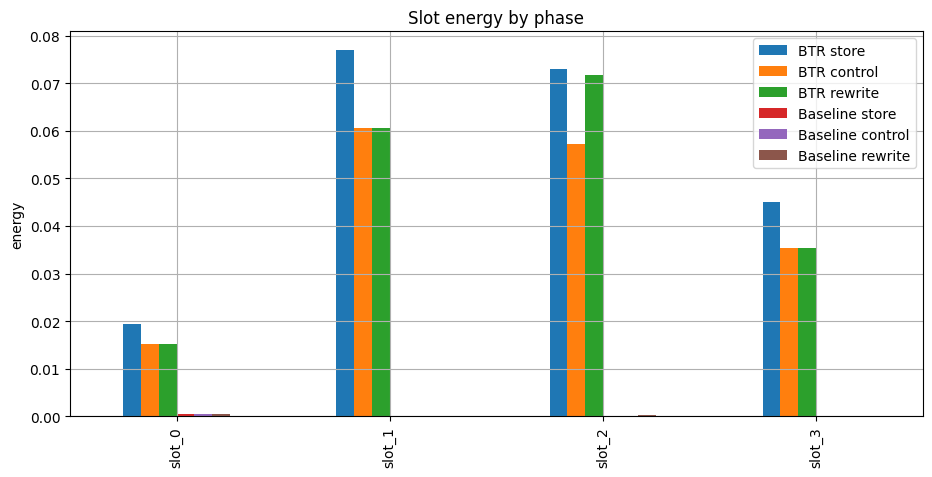

In [11]:

energy_df.plot(kind="bar", figsize=(11, 5))
plt.title("Slot energy by phase")
plt.ylabel("energy")
plt.show()



## Retrieval confusion


In [12]:

triadic_conf = pd.crosstab(triadic_probe["target_slot"], triadic_probe["pred_slot"])
baseline_conf = pd.crosstab(baseline_probe["target_slot"], baseline_probe["pred_slot"])

print("BTR confusion matrix")
triadic_conf


BTR confusion matrix


pred_slot,0,1,2,3
target_slot,,,,
0,14,4,3,3
1,4,13,5,2
2,1,1,18,4
3,8,5,4,7


In [13]:

print("Baseline confusion matrix")
baseline_conf


Baseline confusion matrix


pred_slot,0,1,2,3
target_slot,,,,
0,6,6,2,10
1,1,14,4,5
2,5,2,10,7
3,6,6,5,7



## Read the result

What you want to see:

- **BTR** should beat the baseline on retrieval accuracy
- **BTR** should beat the baseline on recall similarity
- **BTR** should keep higher slot divergence after supervised store
- **BTR** should show better rewrite isolation:
  - larger target isolated shift
  - smaller collateral isolated shift
  - higher rewrite isolation ratio

This is the first explicit slot-contract benchmark.
